In [1]:
from pathlib import Path

import mdna
import mdtraj as md
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

from collections import defaultdict
from scipy.spatial.distance import pdist  

mpl.rcParams.update({
    "font.family": "Palatino",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 300,   # display
    "savefig.dpi": 300,  # saved files
})

In [2]:
path = "./testfiles/1ns_RNA_hairpin_unfolding"
topf = f"{path}/dry.pdb"     
trajf = f"{path}/dry.xtc"
rna = mdna.load(filename=trajf, top=topf, circular=False)

In [3]:
rna.describe()
step_params, step_names = rna.get_parameters(step=True)

single-stranded nucleic acid with 44 nucleotides
Sequence: GGGUGUGGCUGUCACUCGGCUGCAUGCUUAGUGCACUCACGCCC
Trajectory: <mdtraj.Trajectory with 101 frames, 1404 atoms, 44 residues, and unitcells>
Frames not loaded


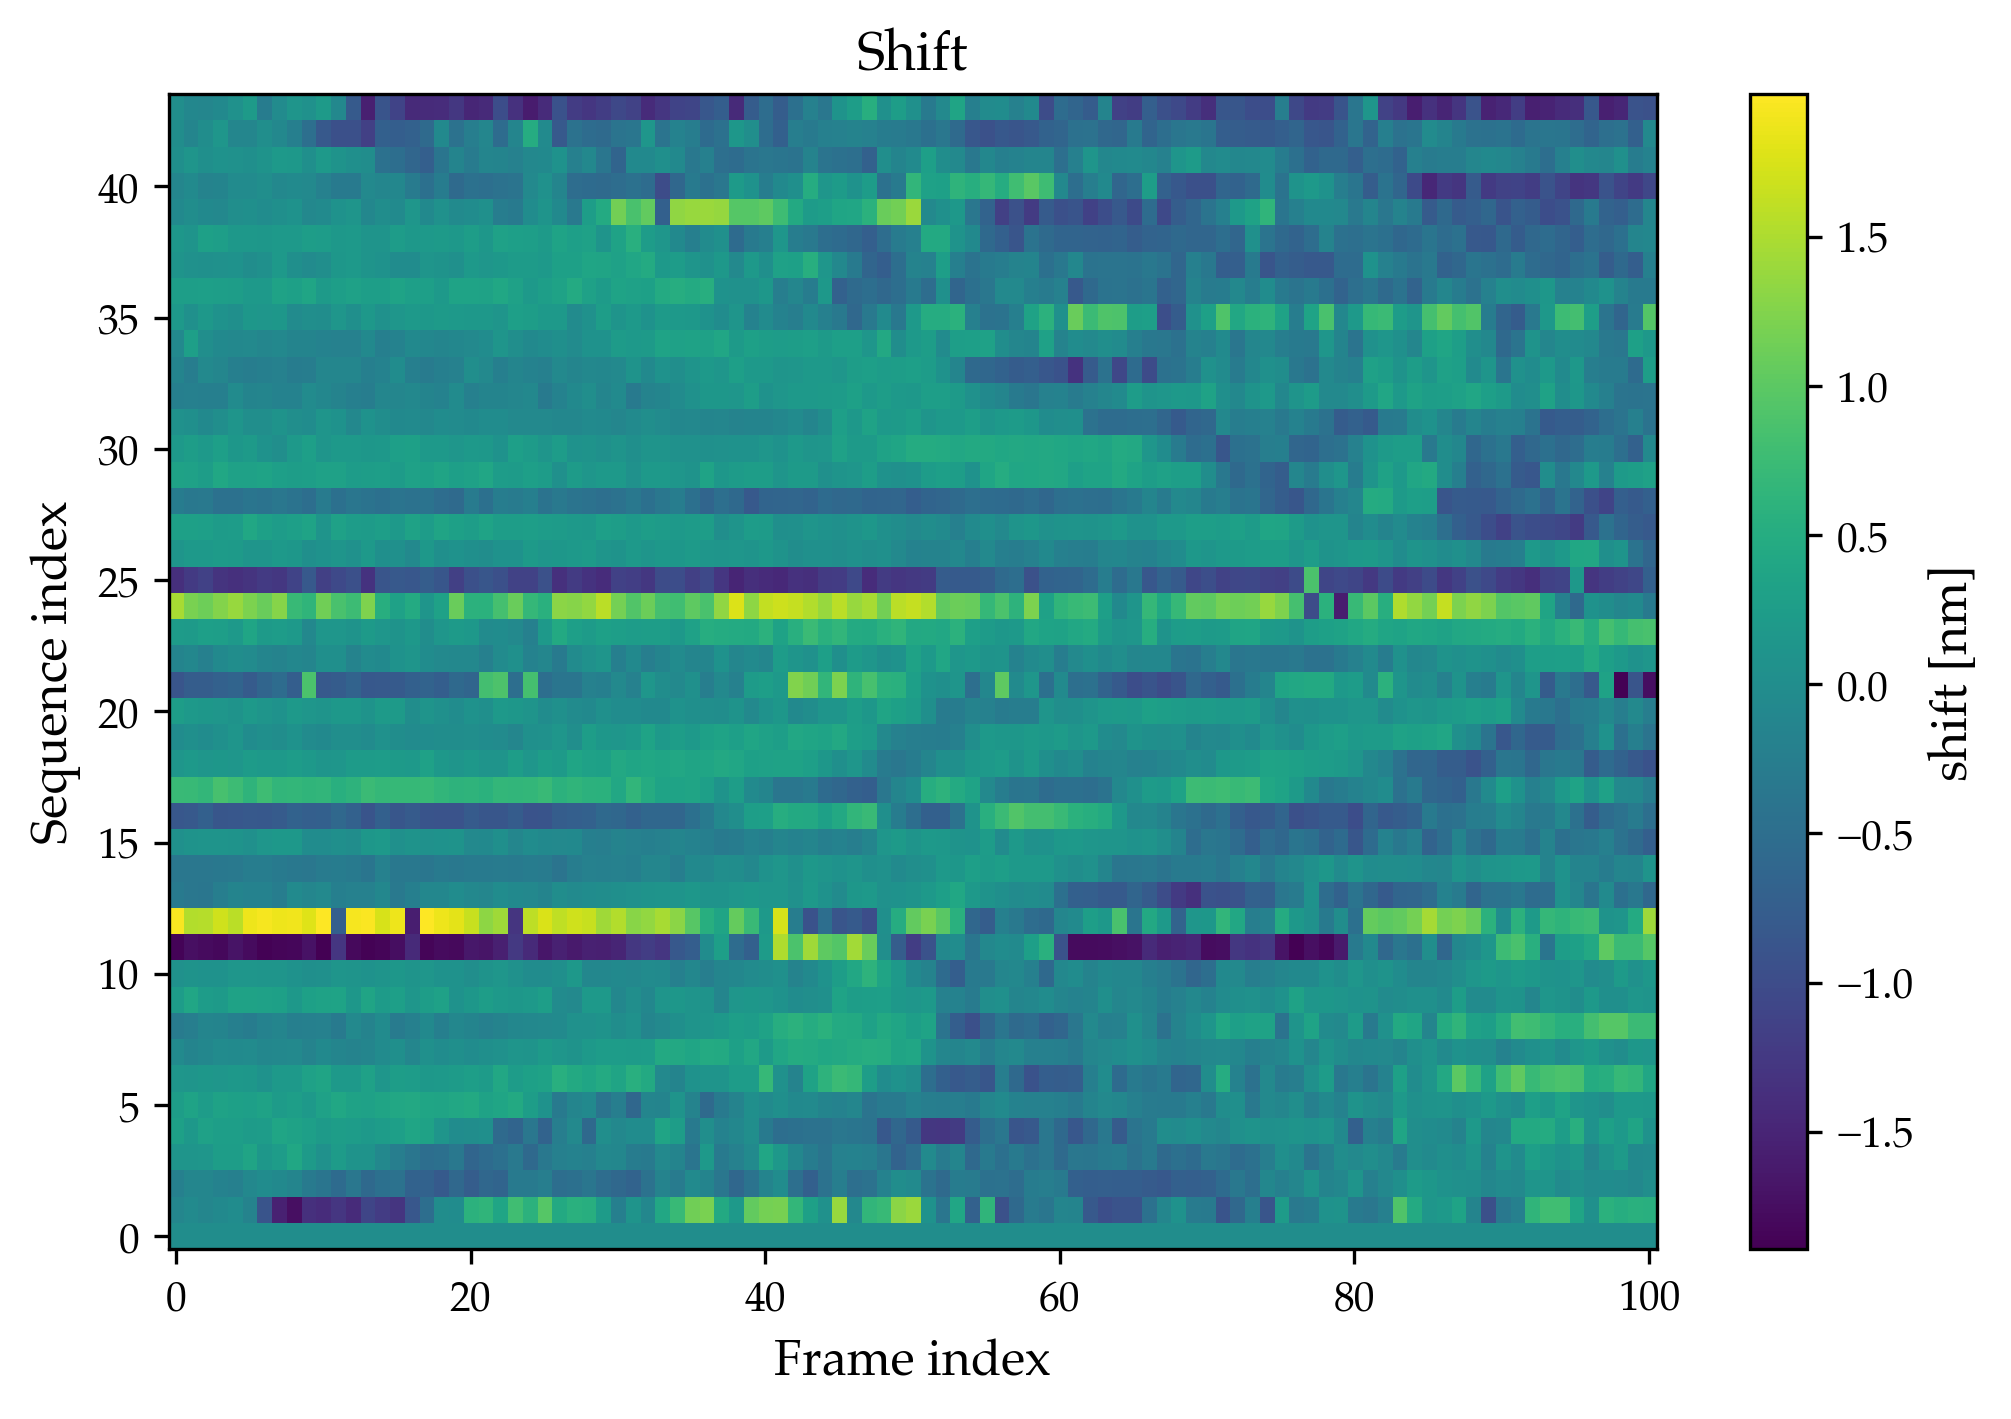

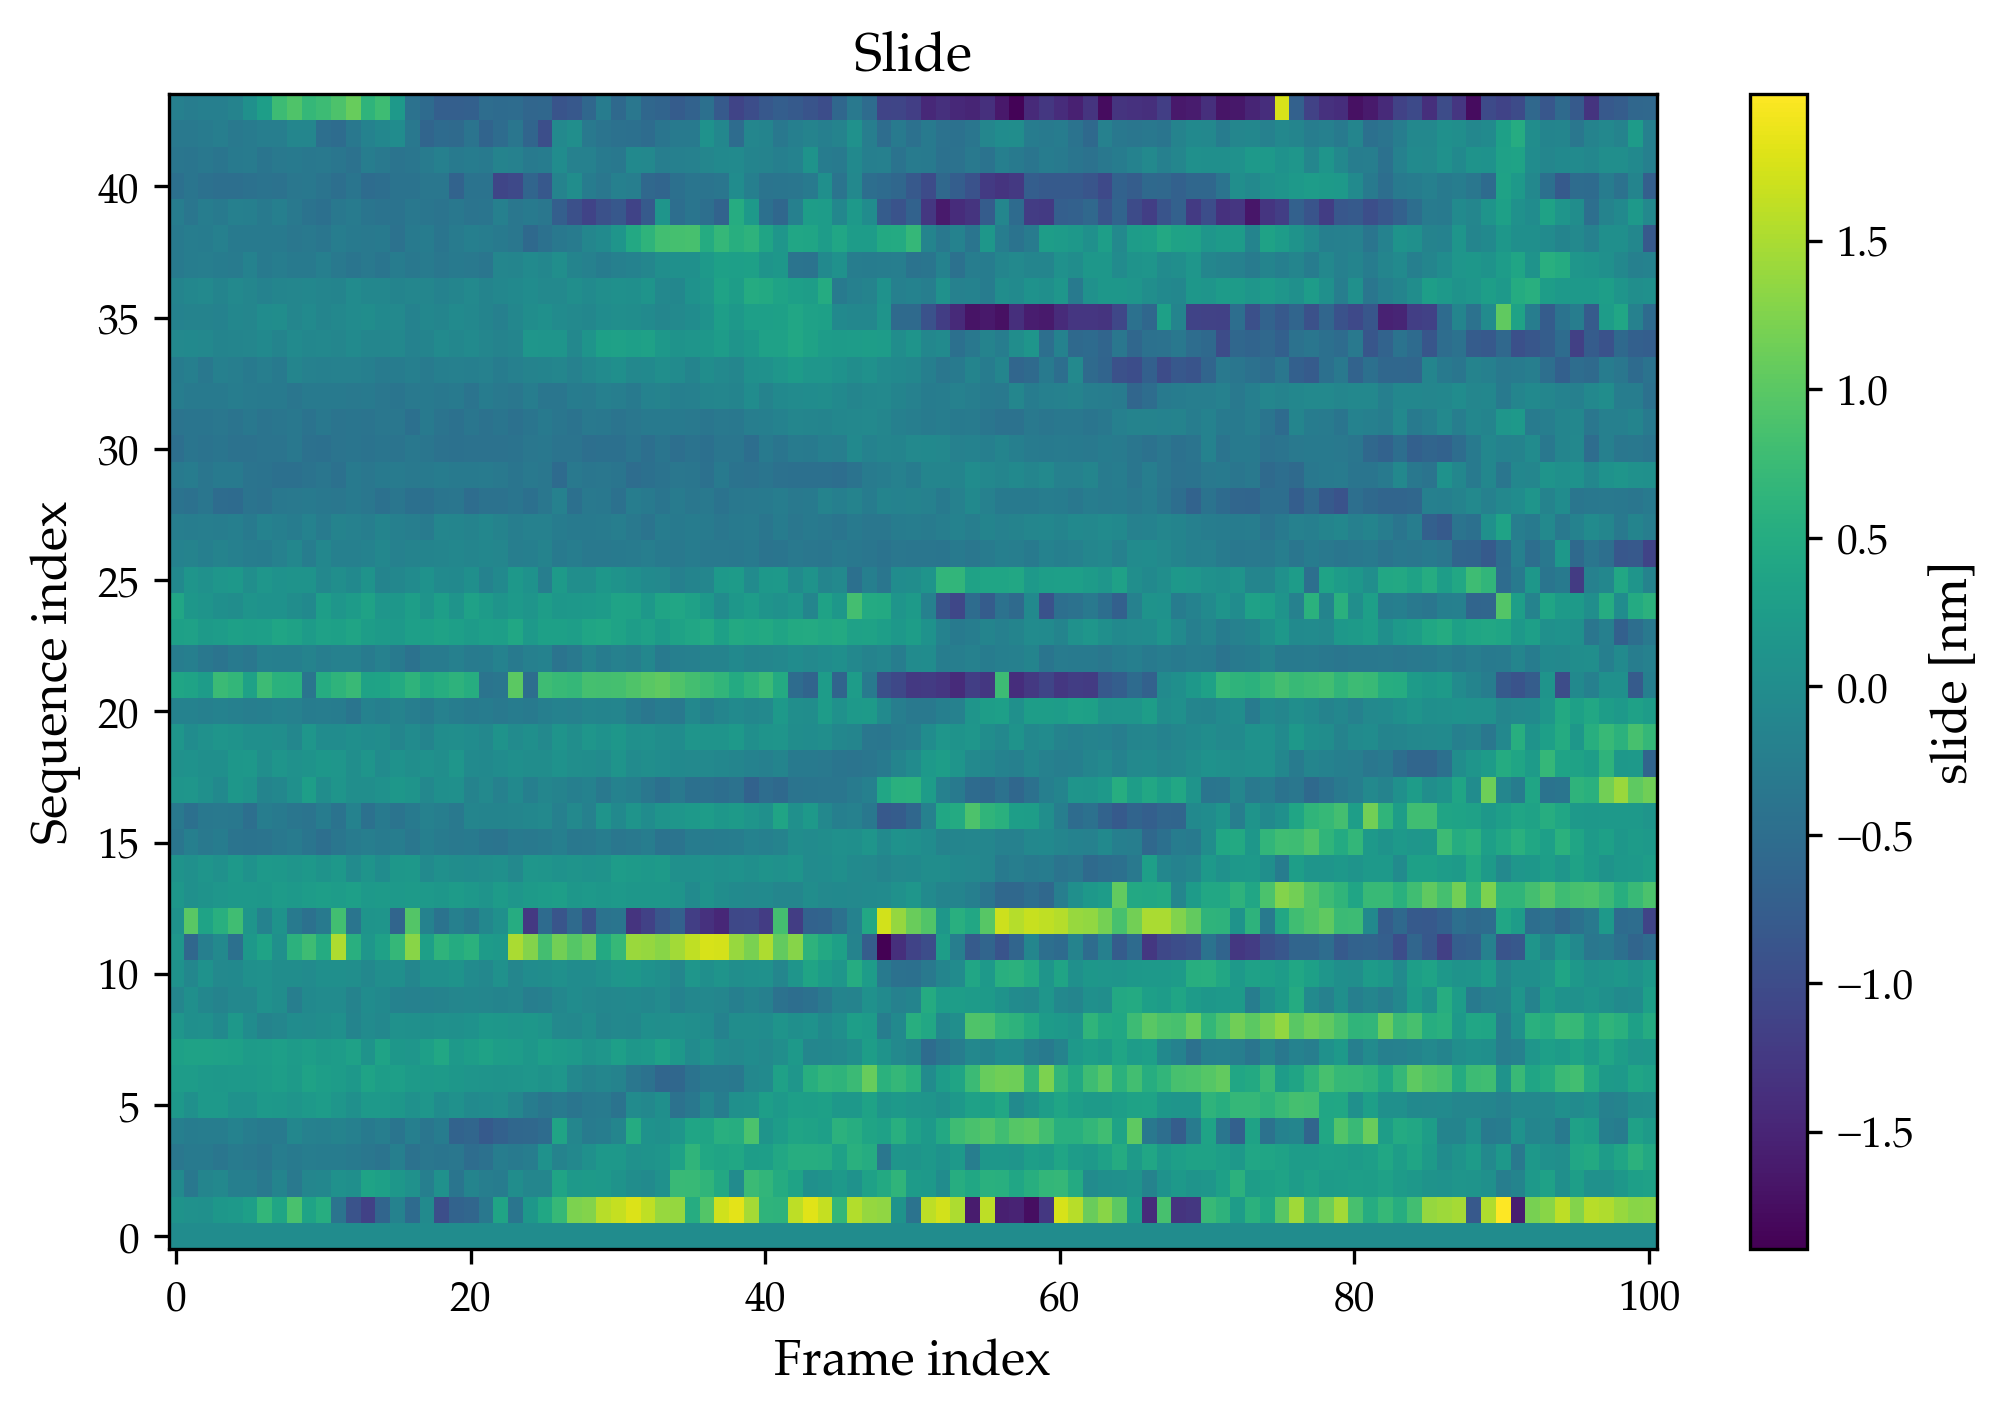

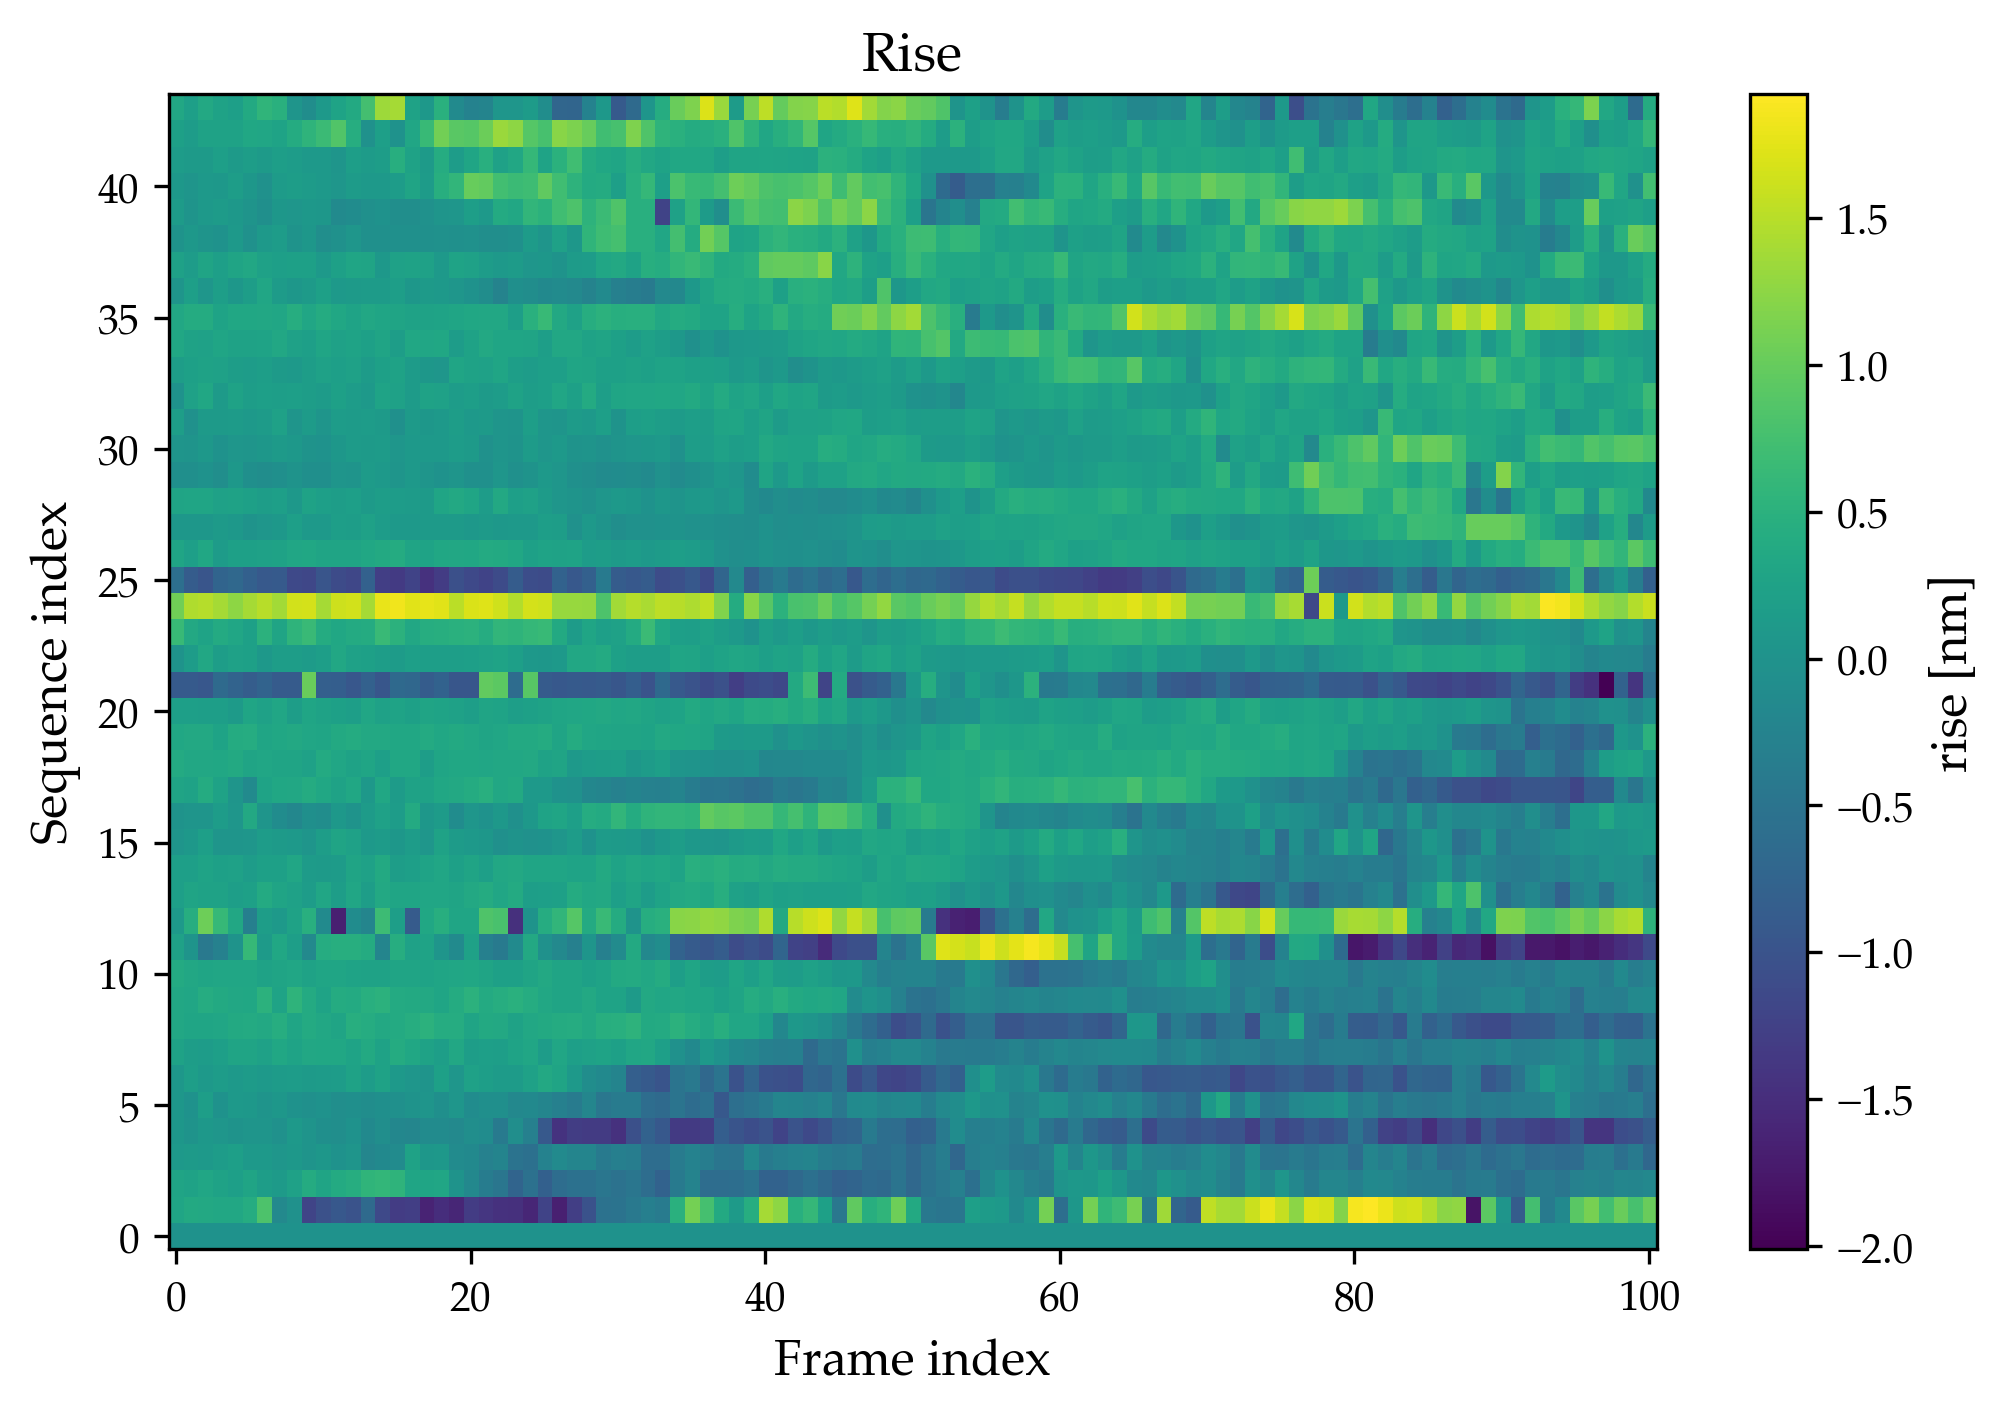

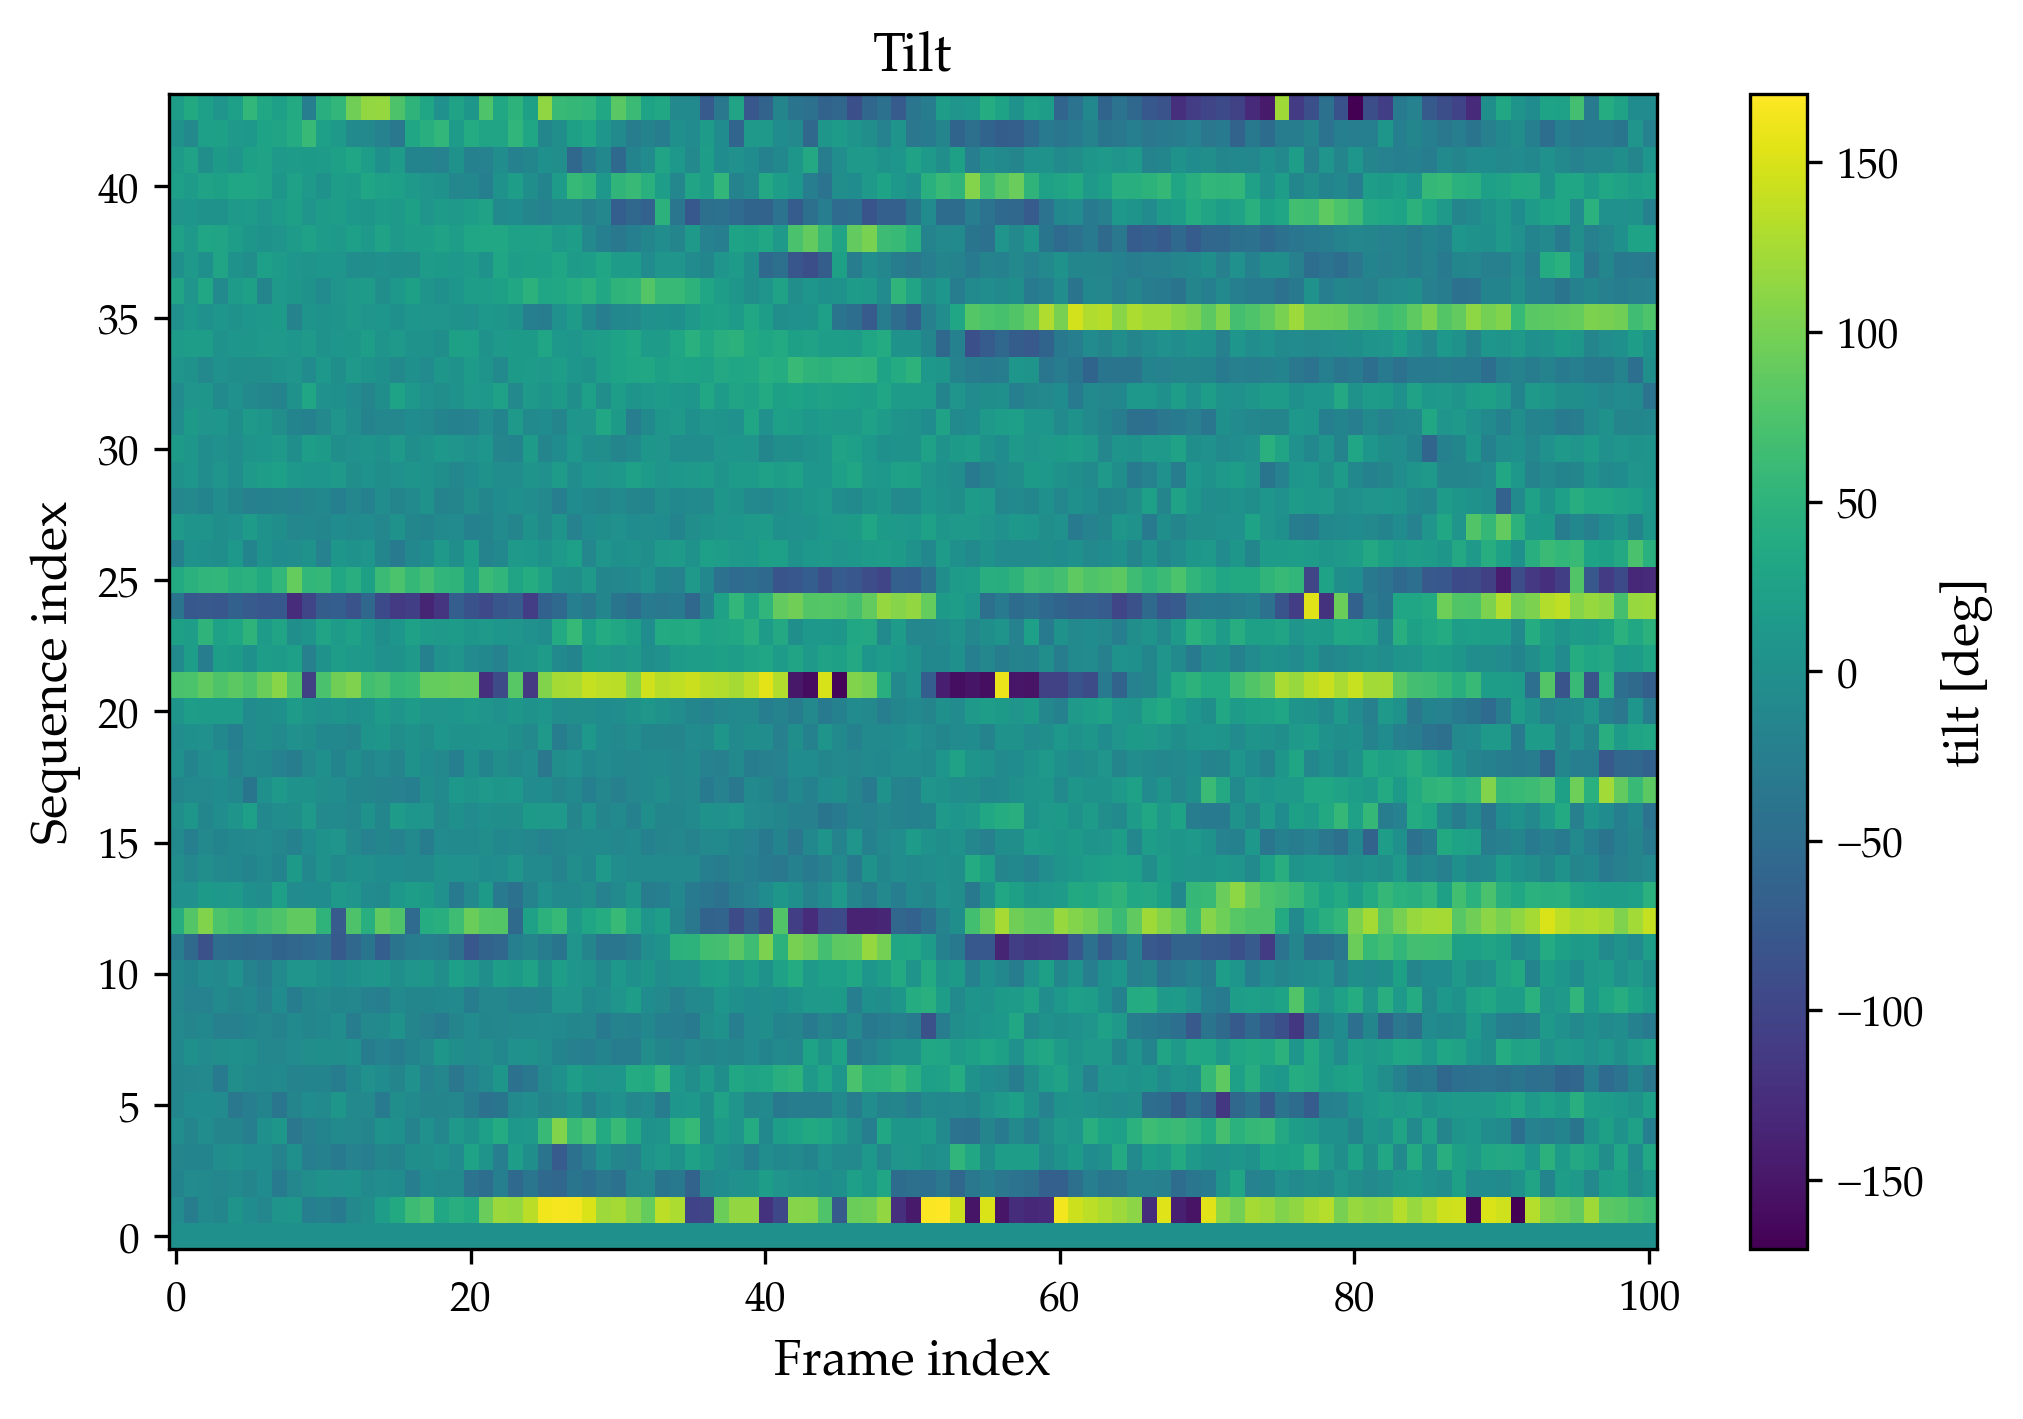

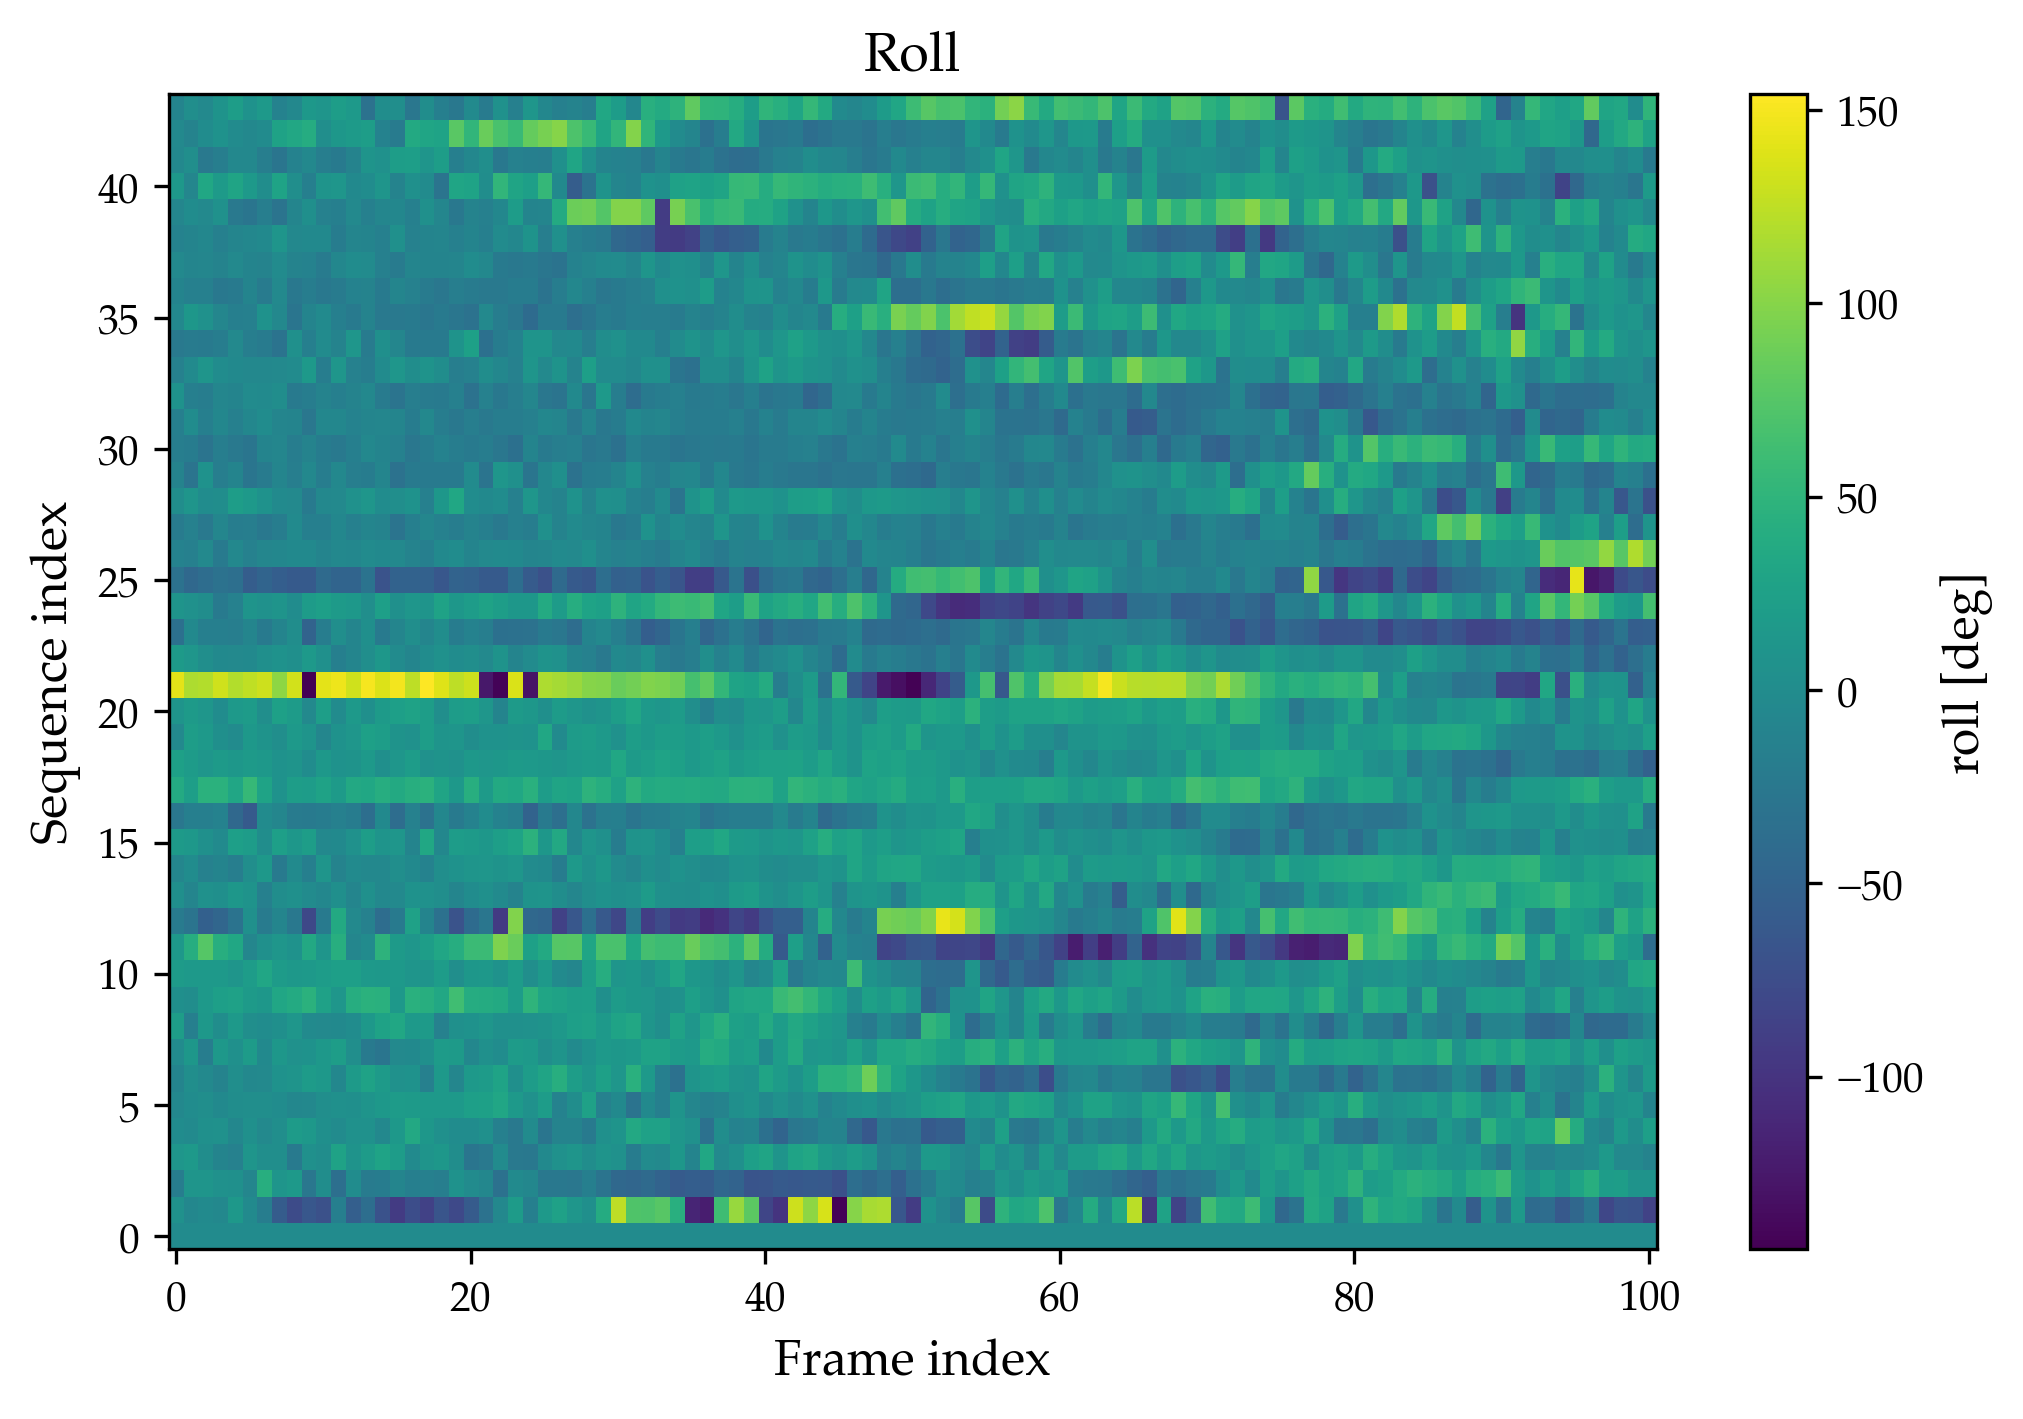

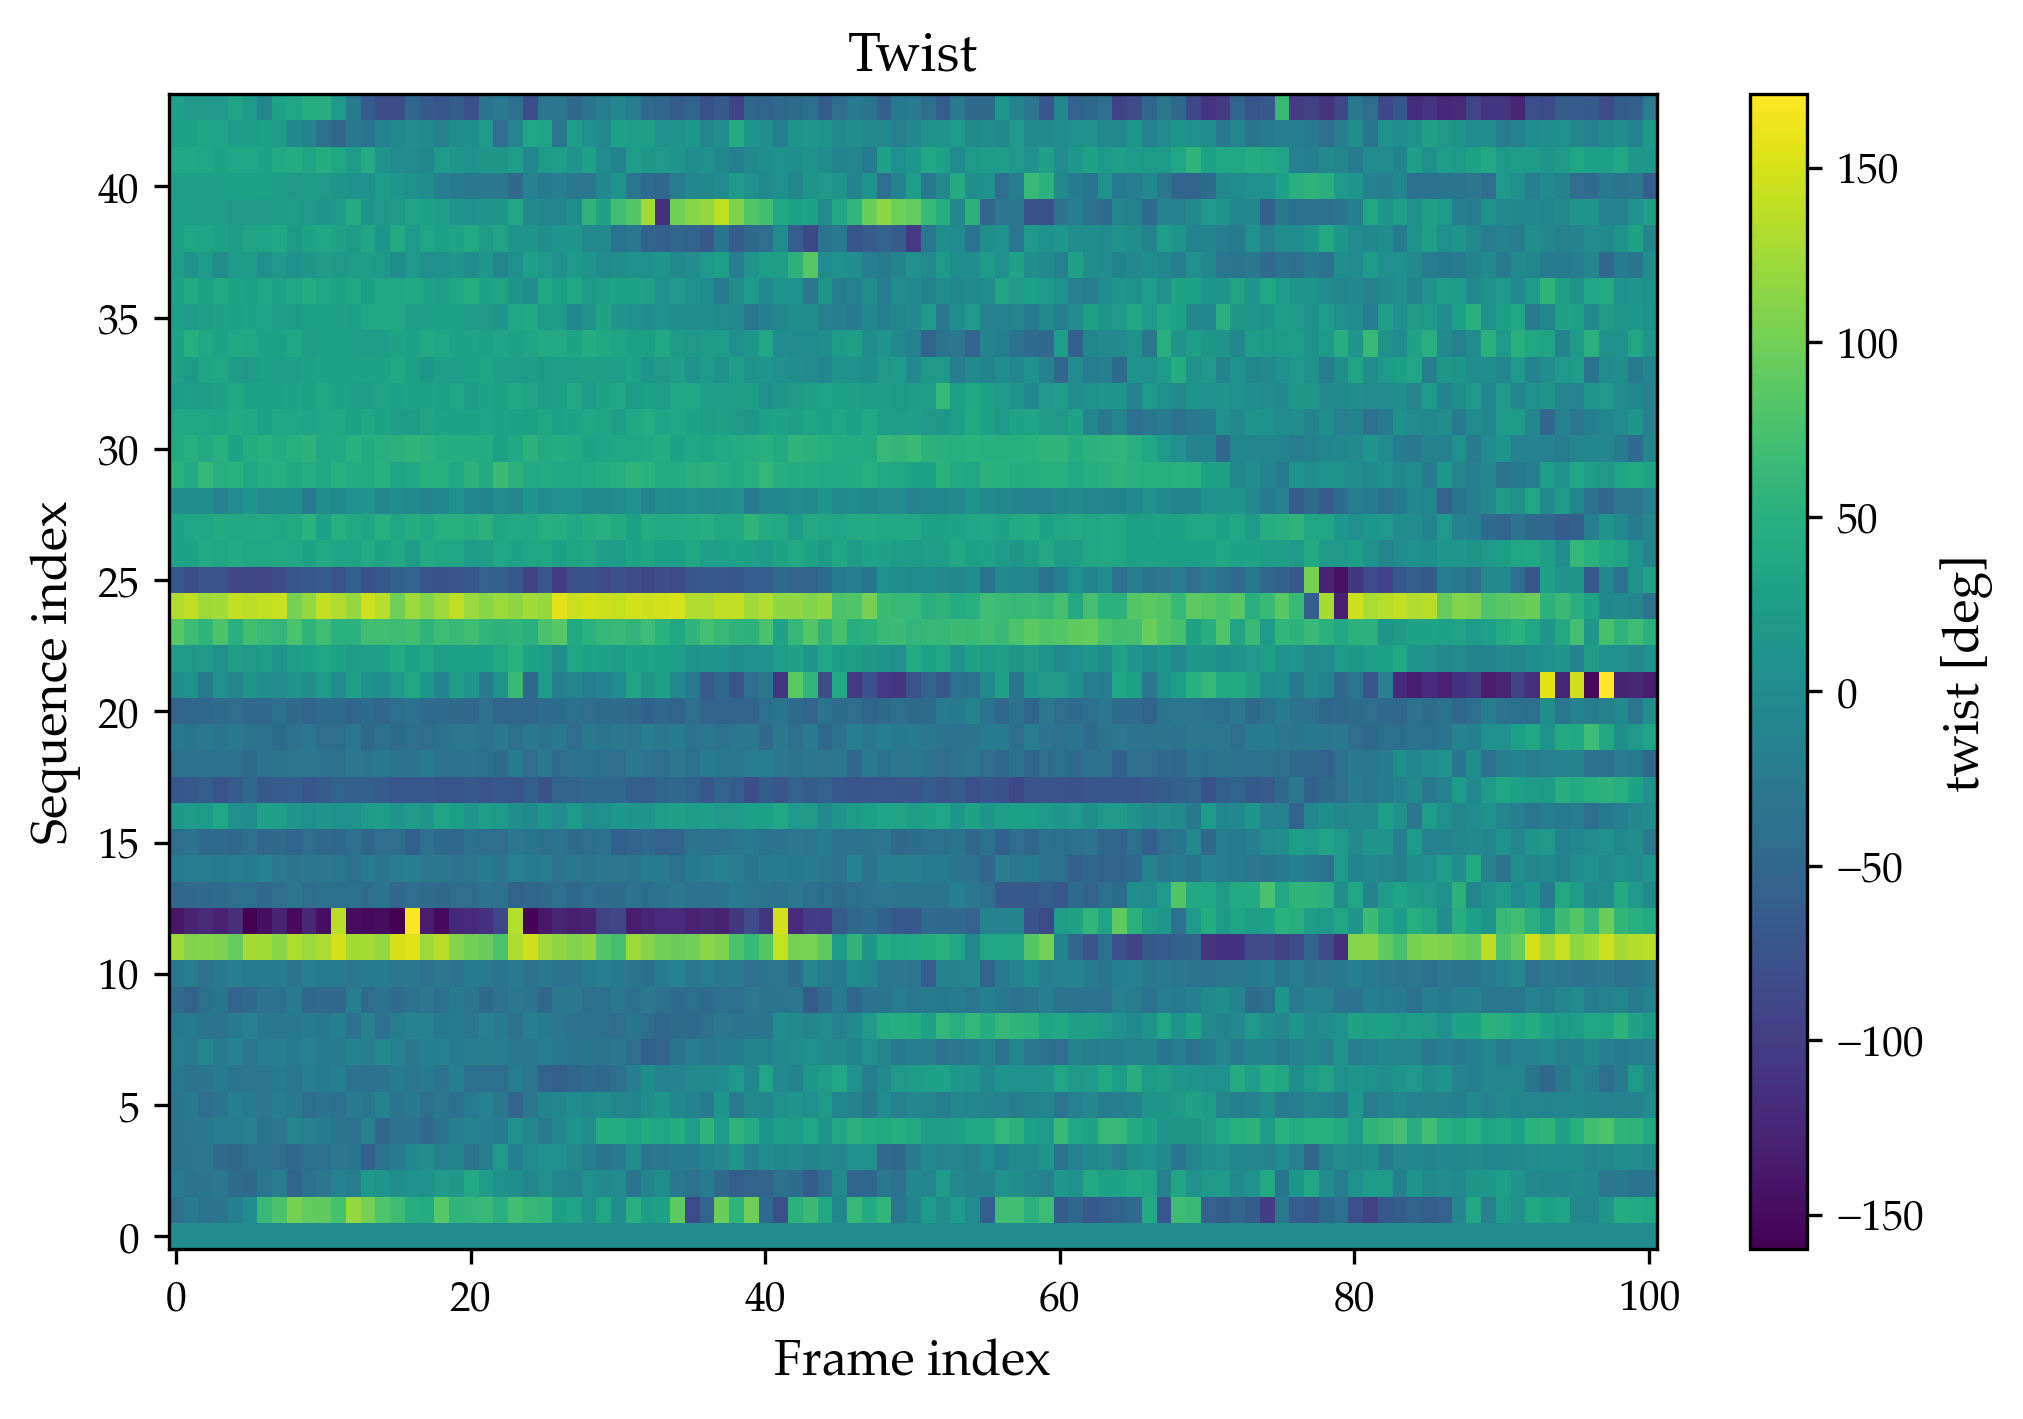

In [7]:
for pname in step_names:
    arr_T = np.asarray(rna.get_parameter(pname), float).T
    is_len = pname in {"shift", "slide", "rise"}
    data = arr_T / 10.0 if is_len else arr_T  # Å -> nm for length params
    label = f"{pname} [{'nm' if is_len else 'deg'}]"

    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(data, origin="lower", aspect="auto")
    ax.set_title(pname.capitalize())
    ax.set_xlabel("Frame index")
    ax.set_ylabel("Sequence index")
    fig.colorbar(im, ax=ax, label=label)
    plt.show()
